In [2]:
!git clone https://github.com/hoangquan1503/Walmart_sales_forecasting.git

fatal: destination path 'Walmart_sales_forecasting' already exists and is not an empty directory.


In [3]:
#!pip uninstall -y numpy pandas matplotlib seaborn prophet cmdstanpy torchmetrics scikit-learn lightgbm optuna shap pyarrow joblib streamlit torch && pip install numpy==1.26.4 pandas==2.2.2 matplotlib==3.7.2 seaborn==0.13.2 prophet==1.1.4 cmdstanpy==1.2.5 torchmetrics==1.3.0 scikit-learn==1.5.1 lightgbm==4.3.0 optuna==3.6.1 shap==0.44.1 pyarrow==20.0.0 joblib==1.4.2 streamlit==1.35.0 torch==2.3.0

In [4]:
import matplotlib
print(matplotlib.__version__)

3.10.0


In [5]:
%cd Walmart_sales_forecasting
!git pull

/content/Walmart_sales_forecasting
remote: Enumerating objects: 16, done.
remote: Counting objects: 100% (16/16), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 9 (delta 3), reused 9 (delta 3), pack-reused 0 (from 0)
Unpacking objects: 100% (9/9), 4.81 KiB | 35.00 KiB/s, done.
From https://github.com/hoangquan1503/Walmart_sales_forecasting
   82c94a9..c62f04a  master     -> origin/master
Updating 82c94a9..c62f04a
Fast-forward
 notebook/EDA.ipynb                 |  489 +----
 notebook/feature_engineering.ipynb | 3677 +++++-------------------------------
 notebook/model.ipynb               |   24 +-
 notebook/preprocessing.ipynb       |  245 +--
 src/metrics.py                     |    7 +
 5 files changed, 649 insertions(+), 3793 deletions(-)
 create mode 100644 src/metrics.py


In [6]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import numpy as np
import pandas as pd
import kagglehub
from kagglehub import KaggleDatasetAdapter


# Set the path to the file you'd like to load


# Load the latest version
train = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "aslanahmedov/walmart-sales-forecast",
  "train.csv",
)
stores = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "aslanahmedov/walmart-sales-forecast",
  "stores.csv",
)
features = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "aslanahmedov/walmart-sales-forecast",
  "features.csv",
)

df = train.merge(stores, on='Store').merge(features, on=['Store', 'Date'])

df.drop(columns=['IsHoliday_y'], inplace=True)
df.rename(columns={'IsHoliday_x' : 'IsHoliday'}, inplace=True)

print("First 5 records:", df.head())

/tmp/ipykernel_6261/2760102447.py:13: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  train = kagglehub.load_dataset(


Using Colab cache for faster access to the 'walmart-sales-forecast' dataset.


/tmp/ipykernel_6261/2760102447.py:18: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  stores = kagglehub.load_dataset(


Using Colab cache for faster access to the 'walmart-sales-forecast' dataset.


/tmp/ipykernel_6261/2760102447.py:23: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  features = kagglehub.load_dataset(


Using Colab cache for faster access to the 'walmart-sales-forecast' dataset.
First 5 records:    Store  Dept        Date  Weekly_Sales  IsHoliday Type    Size  Temperature  \
0      1     1  2010-02-05      24924.50      False    A  151315        42.31   
1      1     1  2010-02-12      46039.49       True    A  151315        38.51   
2      1     1  2010-02-19      41595.55      False    A  151315        39.93   
3      1     1  2010-02-26      19403.54      False    A  151315        46.63   
4      1     1  2010-03-05      21827.90      False    A  151315        46.50   

   Fuel_Price  MarkDown1  MarkDown2  MarkDown3  MarkDown4  MarkDown5  \
0       2.572        NaN        NaN        NaN        NaN        NaN   
1       2.548        NaN        NaN        NaN        NaN        NaN   
2       2.514        NaN        NaN        NaN        NaN        NaN   
3       2.561        NaN        NaN        NaN        NaN        NaN   
4       2.625        NaN        NaN        NaN        NaN  

In [7]:
df['Date'] = pd.to_datetime(df['Date'])
df['Date']

,Date
0,2010-02-05
1,2010-02-12
2,2010-02-19
3,2010-02-26
4,2010-03-05
...,...
421565,2012-09-28
421566,2012-10-05
421567,2012-10-12
421568,2012-10-19


In [8]:
from src.data_cleaning import check_missing_value, fill_missing_promote

check_missing_value(df)



,counts,ratio
Store,0,0.000000
Dept,0,0.000000
Date,0,0.000000
Weekly_Sales,0,0.000000
IsHoliday,0,0.000000
Type,0,0.000000
Size,0,0.000000
Temperature,0,0.000000
Fuel_Price,0,0.000000
MarkDown1,270889,0.642572


In [9]:
markdown = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
df_filled = fill_missing_promote(df, markdown)



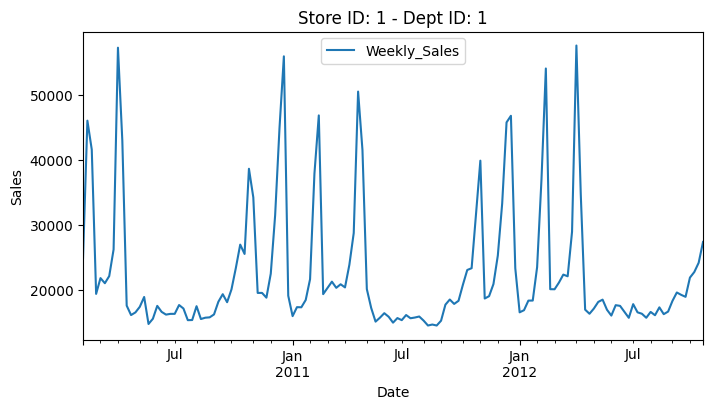

In [10]:
from src.plots import plot_sales

plot_sales(df_filled, 1, 1)

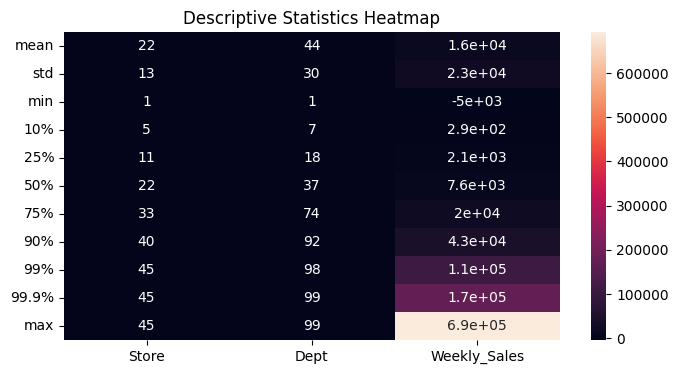

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
summary = (
    df_filled[['Store', 'Dept', 'Weekly_Sales']].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.99, 0.999])
    .iloc[1:]
)
plt.figure(figsize=(8, 4)) 
sns.heatmap(summary, cmap='rocket', annot = True)
plt.title("Descriptive Statistics Heatmap")
plt.show()

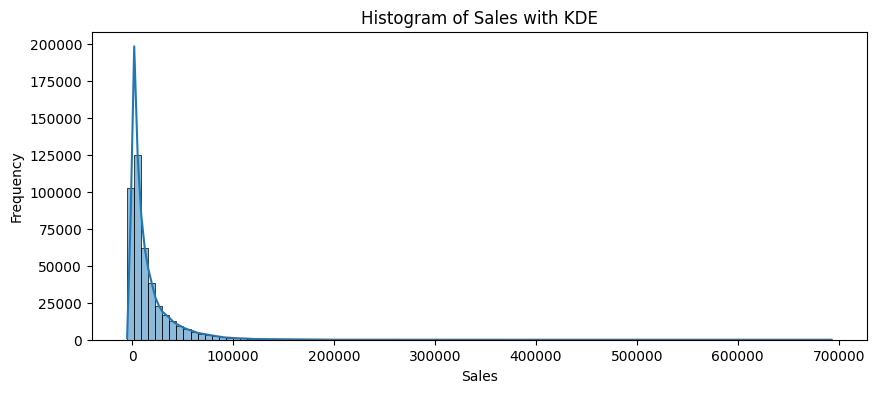

In [12]:
plt.figure(figsize=(10,4))
sns.histplot(df_filled['Weekly_Sales'], bins=100, kde=True)
plt.title('Histogram of Sales with KDE')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.show()

as we can see, there are outliers in this dataset

In [13]:
from src.data_cleaning import corrected_outlier
df_corrected = corrected_outlier(df_filled)
df_corrected

,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
0,1,1,2010-02-05,24924.50,False,A,151315,42.31,2.572,0.00,0.00,0.00,0.00,0.00,211.096358,8.106
1,1,1,2010-02-12,46039.49,True,A,151315,38.51,2.548,0.00,0.00,0.00,0.00,0.00,211.242170,8.106
2,1,1,2010-02-19,41595.55,False,A,151315,39.93,2.514,0.00,0.00,0.00,0.00,0.00,211.289143,8.106
3,1,1,2010-02-26,19403.54,False,A,151315,46.63,2.561,0.00,0.00,0.00,0.00,0.00,211.319643,8.106
4,1,1,2010-03-05,21827.90,False,A,151315,46.50,2.625,0.00,0.00,0.00,0.00,0.00,211.350143,8.106
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421565,45,98,2012-09-28,508.37,False,B,118221,64.88,3.997,4556.61,20.64,1.50,1601.01,3288.25,192.013558,8.684
421566,45,98,2012-10-05,628.10,False,B,118221,64.89,3.985,5046.74,0.00,18.82,2253.43,2340.01,192.170412,8.667
421567,45,98,2012-10-12,1061.02,False,B,118221,54.47,4.000,1956.28,0.00,7.89,599.32,3990.54,192.327265,8.667
421568,45,98,2012-10-19,760.01,False,B,118221,56.47,3.969,2004.02,0.00,3.18,437.73,1537.49,192.330854,8.667


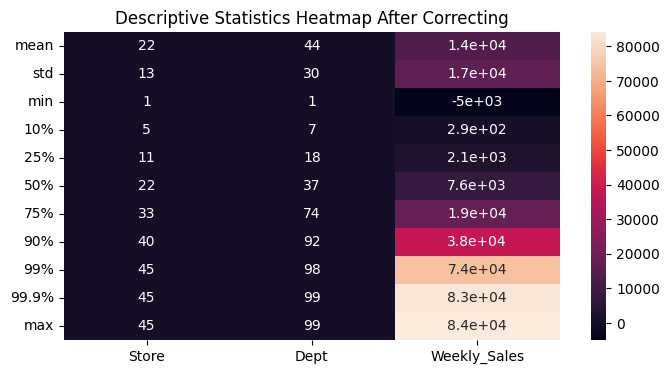

In [14]:
summary = (
    df_corrected[['Store', 'Dept', 'Weekly_Sales']].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.99, 0.999])
    .iloc[1:]
)
plt.figure(figsize=(8, 4)) 
sns.heatmap(summary, cmap='rocket', annot = True)
plt.title("Descriptive Statistics Heatmap After Correcting")
plt.show()

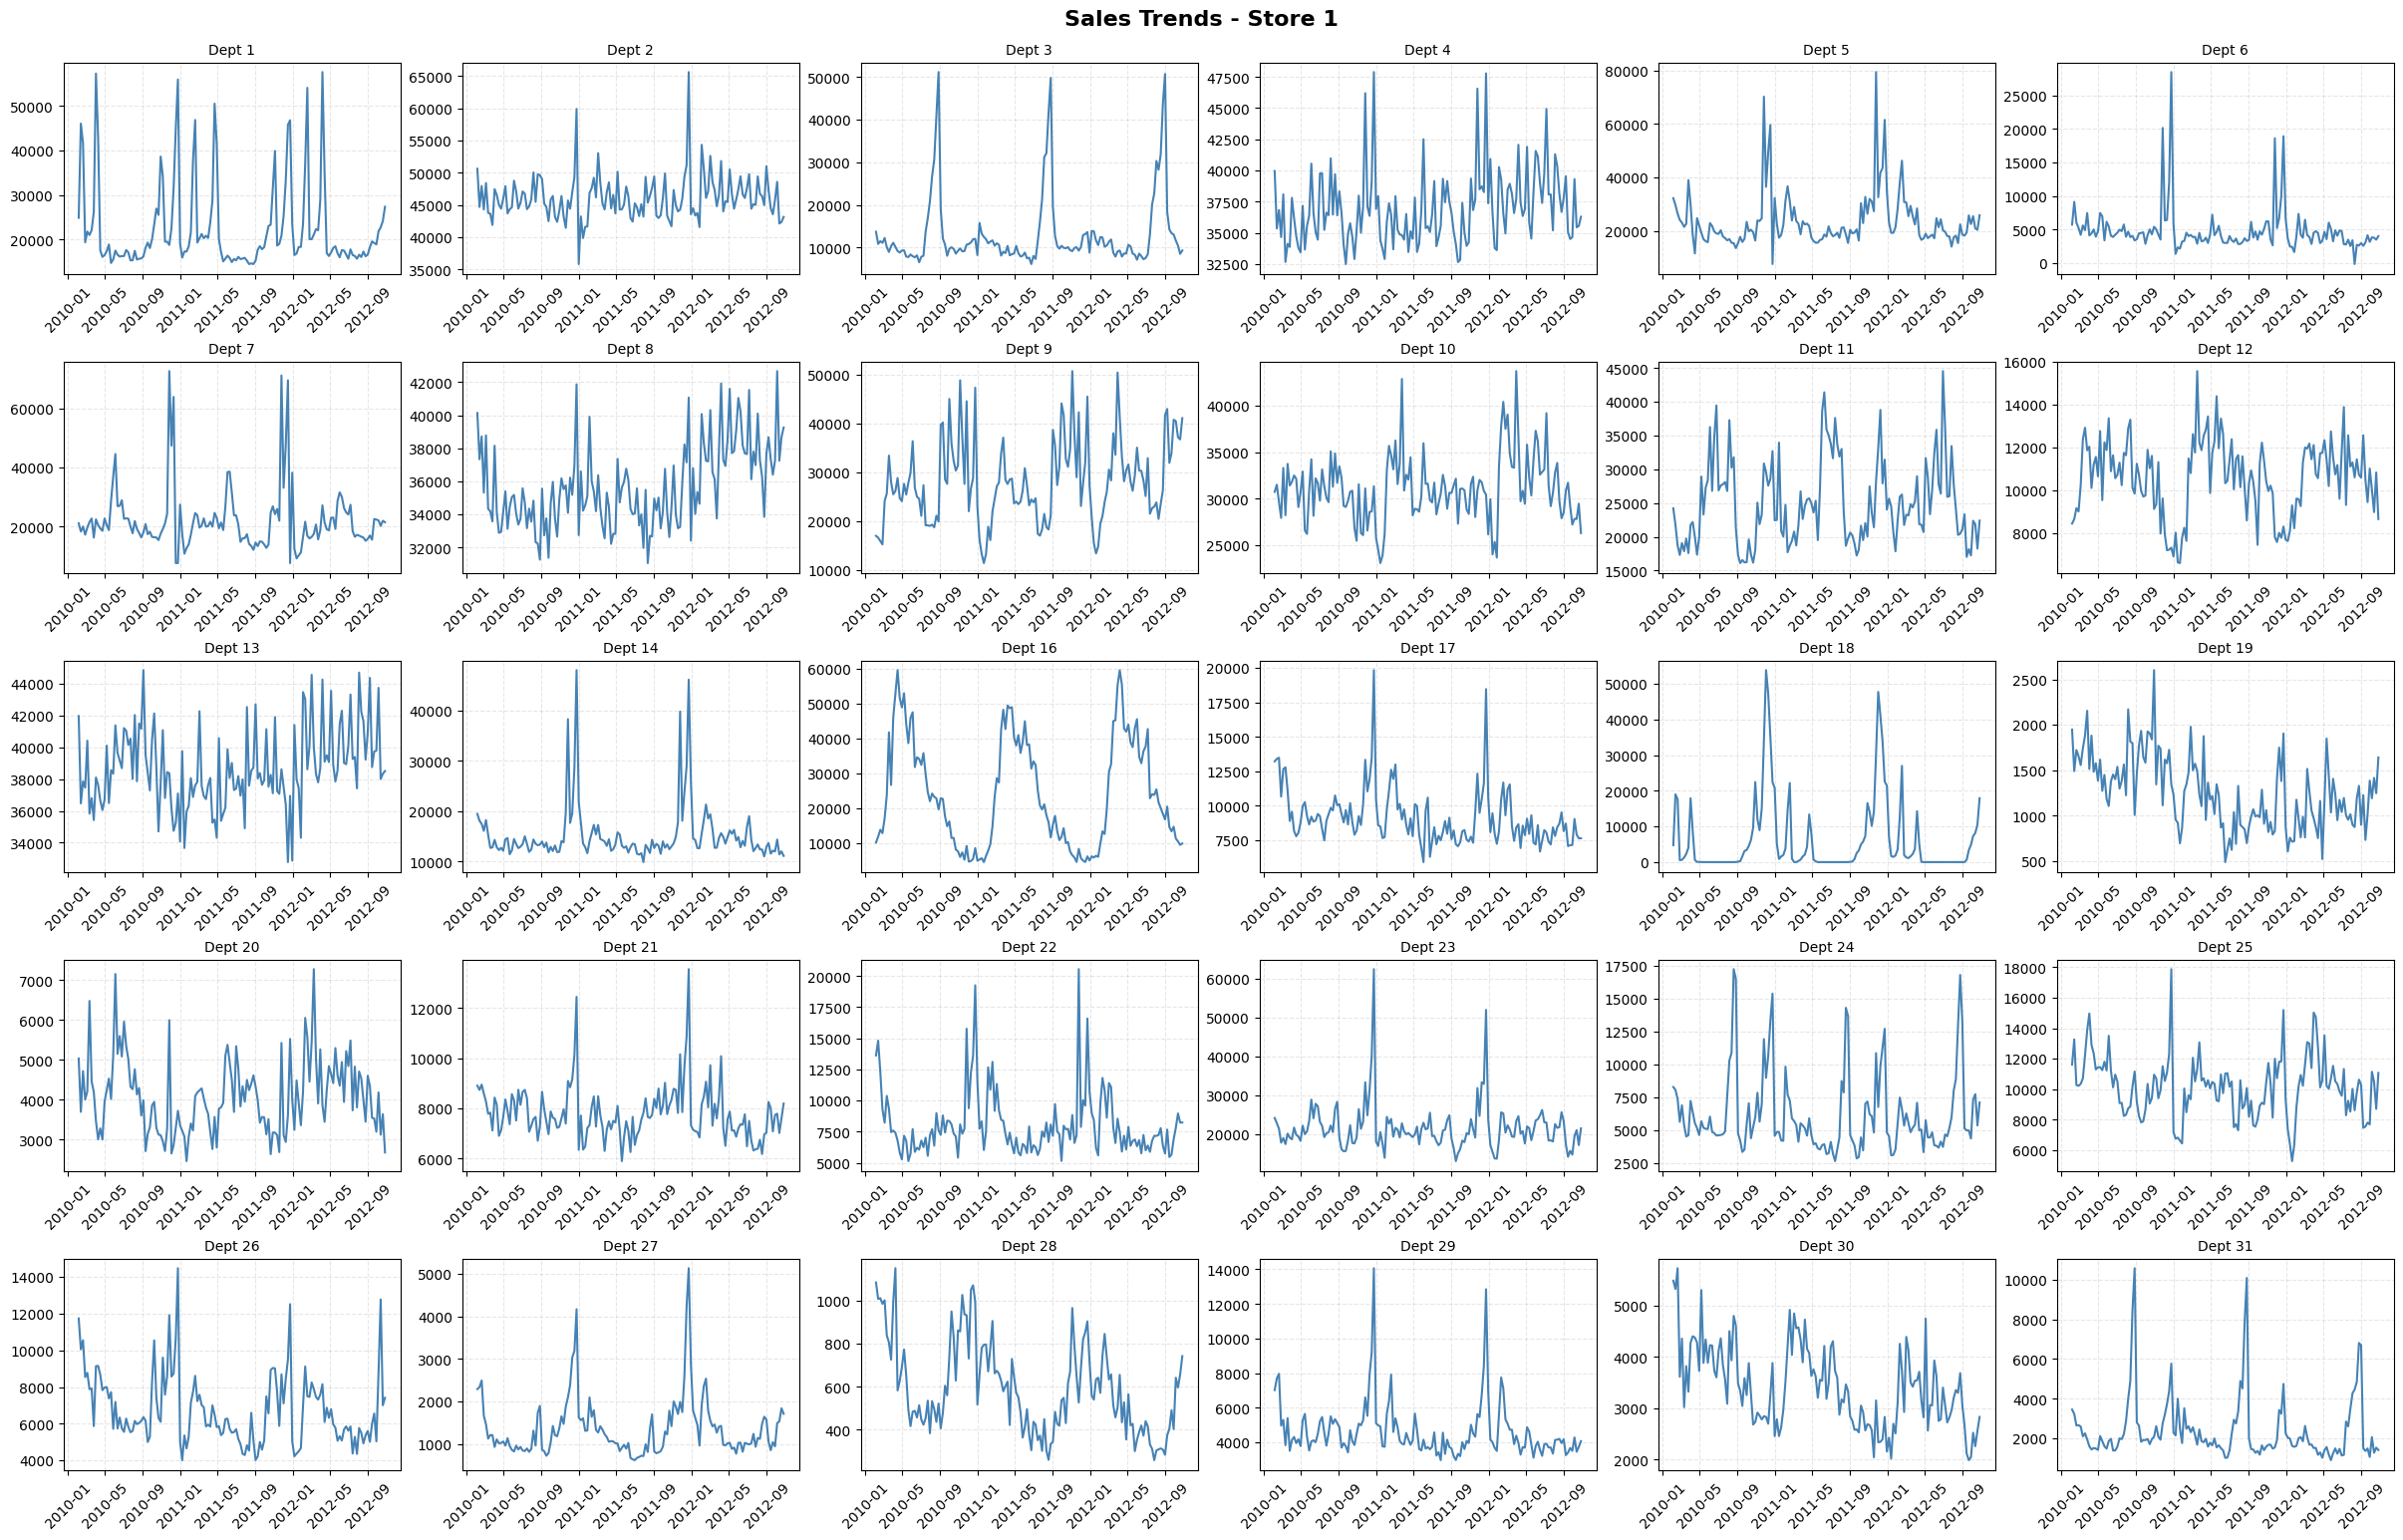

In [15]:
store_id = 1
df_store = df_corrected[df_corrected['Store'] == store_id]
dept_list = df_store['Dept'].unique()  


if len(dept_list) > 30:
    dept_list = dept_list[:30]  

n_rows, n_cols = 5, 6
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*4, n_rows*3), constrained_layout=True)
axes = axes.flatten()

for idx, dept in enumerate(dept_list):
    df_dept = df_store[df_store['Dept'] == dept].sort_values('Date')
    ax = axes[idx]
    ax.plot(df_dept['Date'], df_dept['Weekly_Sales'], color='steelblue', linewidth=1.5)
    ax.set_title(f'Dept {dept}', fontsize=10)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, linestyle='--', alpha=0.3)


for ax in axes[len(dept_list):]:
    ax.axis('off')

fig.suptitle(f'Sales Trends - Store {store_id}', fontsize=16, fontweight='bold', y=1.02)
plt.show()

In [16]:
import os

# position
%cd /content/Walmart_sales_forecasting


os.makedirs("data/processed", exist_ok=True)


save_file = "data/processed/sales_data_preprocessed.csv"

# save file
df_corrected.to_csv(save_file, index=False)

/content/Walmart_sales_forecasting


In [17]:
%cd /content/Walmart_sales_forecasting/data/processed/
!ls


/content/Walmart_sales_forecasting/data/processed
feature_engineering.feather  sales_data_preprocessed.csv
